<a href="https://colab.research.google.com/github/Avi0095/Deep-Learning/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import the training set

In [52]:
dataset_train=pd.read_csv('/content/Google_Stock_Price_Train.csv')
training_set=dataset_train.iloc[:,1:2].values

feature scaling

In [53]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler(feature_range=(0,1))
training_set_scaled=sc.fit_transform(training_set)
training_set_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

creating a datastructure with 60 timespace and 1 output

In [54]:
x_train=[]
y_train=[]
for i in range(60,1258):
  x_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
x_train,y_train=np.array(x_train),np.array(y_train)

reshaping

In [13]:
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_train

array([[[0.08581368],
        [0.09701243],
        [0.09433366],
        ...,
        [0.07846566],
        [0.08034452],
        [0.08497656]],

       [[0.09701243],
        [0.09433366],
        [0.09156187],
        ...,
        [0.08034452],
        [0.08497656],
        [0.08627874]],

       [[0.09433366],
        [0.09156187],
        [0.07984225],
        ...,
        [0.08497656],
        [0.08627874],
        [0.08471612]],

       ...,

       [[0.92106928],
        [0.92438053],
        [0.93048218],
        ...,
        [0.95475854],
        [0.95204256],
        [0.95163331]],

       [[0.92438053],
        [0.93048218],
        [0.9299055 ],
        ...,
        [0.95204256],
        [0.95163331],
        [0.95725128]],

       [[0.93048218],
        [0.9299055 ],
        [0.93113327],
        ...,
        [0.95163331],
        [0.95725128],
        [0.93796041]]])

In [55]:
split = int(0.8 * len(x_train))
x_train_final =x_train[:split]
y_train_final = y_train[:split]
X_test = x_train[split:]
y_test = y_train[split:]

Building RNN

In [56]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout


initialize RNN

In [57]:
regressor=Sequential()

In [58]:
regressor.add(LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)))
regressor.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))

In [60]:
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))

In [61]:
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

In [62]:
regressor.add(Dense(units=1))

In [63]:
regressor.compile(optimizer='adam', loss='mean_squared_error')

In [64]:
history = regressor.fit(x_train_final, y_train_final, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 0.0654 - val_loss: 0.0281
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0068 - val_loss: 0.0043
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0053 - val_loss: 0.0021
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0049 - val_loss: 0.0020
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0039 - val_loss: 0.0042
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0036 - val_loss: 0.0030
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0034 - val_loss: 0.0029
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.

In [65]:
predicted_stock = regressor.predict(X_test)
predicted_stock = sc.inverse_transform(predicted_stock)
y_test_real = sc.inverse_transform(y_test.reshape(-1,1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


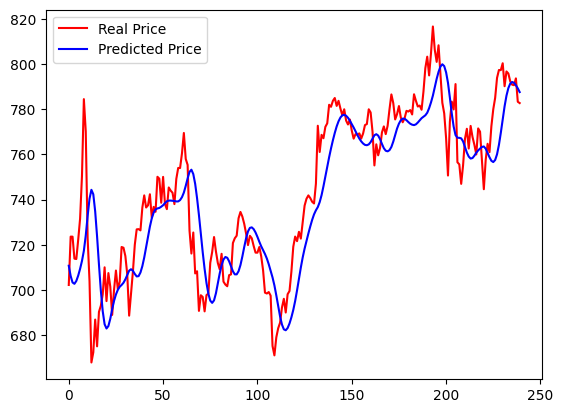

In [71]:
import matplotlib.pyplot as plt

plt.plot(y_test_real, color='red', label='Real Price')
plt.plot(predicted_stock, color='blue', label='Predicted Price')
plt.legend()
plt.show()